In [200]:
# =========================
# GenoScene (Phase 2) – New Dataset Multi-Task Models
# Dataset: final_merged_3.csv
# Models: Logistic Regression (baseline) + LightGBM (new)
# Metrics: Accuracy / Macro-F1 / Log Loss
# Outputs: Multi-task predictor (Eye + Hair + Skin) with probabilities
# =========================

import pandas as pd
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix

from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [201]:
!pip install xgboost

In [202]:
# =========================
# 1) Load Data
# =========================
df = pd.read_csv("final_merged_3.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Targets موجودة في الداتا
EYE_TARGET  = "Predicted_Eye_Color"
HAIR_TARGET = "Predicted_Hair_Color"
SKIN_TARGET = "Predicted_Skin_Color"

# SNP features
snp_cols = [c for c in df.columns if c.startswith("rs")]
print("SNP columns:", len(snp_cols))


Shape: (7734, 60)
Columns: ['sampleid', 'rs11547464_A', 'rs885479_T', 'rs1805008_T', 'rs1805005_T', 'rs1805006_A', 'rs1805007_T', 'rs1805009_C', 'rs201326893_A', 'rs2228479_A', 'rs1110400_C', 'rs28777_C', 'rs16891982_C', 'rs12821256_G', 'rs4959270_A', 'rs12203592_T', 'rs1042602_T', 'rs1800407_A', 'rs2402130_G', 'rs12913832_T', 'rs2378249_C', 'rs12896399_T', 'rs1393350_T', 'rs683_G', 'rs3114908_T', 'rs1800414_C', 'rs10756819_G', 'rs2238289_C', 'rs17128291_C', 'rs6497292_C', 'rs1129038_G', 'rs1667394_C', 'rs1126809_A', 'rs1470608_A', 'rs1426654_G', 'rs6119471_C', 'rs1545397_T', 'rs6059655_T', 'rs12441727_A', 'rs3212355_A', 'rs8051733_C', 'PBlueEye', 'PIntermediateEye', 'PBrownEye', 'Predicted_Eye_Color', 'PBlondHair', 'PBrownHair', 'PRedHair', 'PBlackHair', 'Predicted_Hair_Color', 'PLightHair', 'PDarkHair', 'Predicted_Hair_Shade', 'PVeryPaleSkin', 'PPaleSkin', 'PIntermediateSkin', 'PDarkSkin', 'PDarktoBlackSkin', 'Predicted_Skin_Color', 'Sex_encoded']
SNP columns: 40


In [203]:
# =========================
# 2) Base feature matrix (reproducible; used until Feature Selection replaces per-trait)
# =========================
X = df[snp_cols].values
selected_snps = snp_cols.copy()
print("Base X shape:", X.shape, "| selected_snps count:", len(selected_snps))

Base X shape: (7734, 40) | selected_snps count: 40


In [204]:
# # =========================
# # 2) Optional Data Improvement
# #    Remove near-constant SNPs (very low variance)
# # =========================
# X_raw = df[snp_cols].values

# var_selector = VarianceThreshold(threshold=0.01)  # adjust if needed (0.005 / 0.01 / 0.02)
# X = var_selector.fit_transform(X_raw)

# selected_snps = [snp_cols[i] for i, keep in enumerate(var_selector.get_support()) if keep]
# removed_snps  = [c for c in snp_cols if c not in selected_snps]

# print("Selected SNPs:", len(selected_snps))
# print("Removed SNPs (low variance):", removed_snps)



## Class Merge: Pale + VeryPale

دمج كلاسيّ **VeryPale** و **Pale** تحت اسم واحد **Pale** لتحسين استقرار النموذج وتقليل عدم الاتزان بين الفئات (كلاس VeryPale غالباً قليل العينات). هذا يبقى مقبولاً أكاديمياً لأن كلا الوصفين يقعان في الطيف الفاتح للبشرة.

In [205]:
# Create merged skin target: VeryPale -> Pale
SKIN_TARGET_MERGED = "Predicted_Skin_Color_merged"
df[SKIN_TARGET_MERGED] = df[SKIN_TARGET].replace("VeryPale", "Pale")

# Distribution before merge
before = df[SKIN_TARGET].value_counts().sort_index()
pct_before = (before / len(df) * 100).round(2)
print("--- Before merge (Skin) ---")
print(before)
print("Percentages:\n", pct_before)

# Distribution after merge
after = df[SKIN_TARGET_MERGED].value_counts().sort_index()
pct_after = (after / len(df) * 100).round(2)
print("\n--- After merge (Skin) ---")
print(after)
print("Percentages:\n", pct_after)

--- Before merge (Skin) ---
Predicted_Skin_Color
Dark             609
DarkToBlack     1202
Intermediate    2218
Pale            3679
VeryPale          26
Name: count, dtype: int64
Percentages:
 Predicted_Skin_Color
Dark             7.87
DarkToBlack     15.54
Intermediate    28.68
Pale            47.57
VeryPale         0.34
Name: count, dtype: float64

--- After merge (Skin) ---
Predicted_Skin_Color_merged
Dark             609
DarkToBlack     1202
Intermediate    2218
Pale            3705
Name: count, dtype: int64
Percentages:
 Predicted_Skin_Color_merged
Dark             7.87
DarkToBlack     15.54
Intermediate    28.68
Pale            47.91
Name: count, dtype: float64


## Feature Selection

استخدام **أهمية الميزات من Random Forest** (feature importance) لكل صفة على حدة لاختيار أقوى SNPs المرتبطة بالصفة. الطريقة مناسبة لـ GenoScene لأنها قابلة للتفسير وتتفق مع الأدبيات (جينات مختلفة تؤثر على العين vs الشعر vs البشرة). نختار لكل صفة عدداً ثابتاً من أهم SNPs ثم ندرّب الموديل على هذه المجموعة فقط.

In [206]:
features = [c for c in df.columns if c.startswith("rs")]
targets_fs = {
    "Eye Color": EYE_TARGET,
    "Hair Color": HAIR_TARGET,
    "Skin Color": SKIN_TARGET_MERGED,
}
target_n_features = {"Eye Color": 13, "Hair Color": 35, "Skin Color": 30}
independent_high_impact_snps = {}

for label, target_col in targets_fs.items():
    n = target_n_features[label]
    X_fs = df[features]
    y_fs = df[target_col].astype(str)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fs, y_fs)
    importances = pd.Series(rf.feature_importances_, index=features)
    top_n = importances.nlargest(n).index.tolist()
    independent_high_impact_snps[label] = top_n

for trait, snps in independent_high_impact_snps.items():
    print(f"\n--- {trait} (Top {len(snps)} SNPs) ---")
    print(snps)


--- Eye Color (Top 13 SNPs) ---
['rs12913832_T', 'rs1129038_G', 'rs16891982_C', 'rs1800407_A', 'rs28777_C', 'rs12896399_T', 'rs2238289_C', 'rs1667394_C', 'rs1470608_A', 'rs6059655_T', 'rs683_G', 'rs3212355_A', 'rs12821256_G']

--- Hair Color (Top 35 SNPs) ---
['rs16891982_C', 'rs12913832_T', 'rs1129038_G', 'rs28777_C', 'rs1800407_A', 'rs6059655_T', 'rs12203592_T', 'rs12821256_G', 'rs1426654_G', 'rs683_G', 'rs3212355_A', 'rs1042602_T', 'rs1667394_C', 'rs2238289_C', 'rs1393350_T', 'rs17128291_C', 'rs1470608_A', 'rs1805007_T', 'rs1805008_T', 'rs4959270_A', 'rs8051733_C', 'rs1805005_T', 'rs885479_T', 'rs2378249_C', 'rs10756819_G', 'rs2402130_G', 'rs3114908_T', 'rs12896399_T', 'rs6497292_C', 'rs1545397_T', 'rs1805009_C', 'rs2228479_A', 'rs1126809_A', 'rs12441727_A', 'rs1110400_C']

--- Skin Color (Top 30 SNPs) ---
['rs1426654_G', 'rs16891982_C', 'rs3212355_A', 'rs6059655_T', 'rs1800414_C', 'rs1800407_A', 'rs12821256_G', 'rs28777_C', 'rs885479_T', 'rs12913832_T', 'rs17128291_C', 'rs1129038_

In [207]:
# =========================
# 3) Helper: Metrics
# =========================
def compute_metrics(y_true, y_pred, y_proba, n_classes):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro_F1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "Log_Loss": round(log_loss(y_true, y_proba, labels=list(range(n_classes))), 4)
    }



In [208]:
# =========================
# 4) Train/Eval for one trait
# =========================
def train_eval_trait(trait_name, target_col, X_all):
    # Encode target
    le = LabelEncoder()
    y_all = le.fit_transform(df[target_col].astype(str))
    classes = le.classes_
    n_classes = len(classes)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

    # -------- Logistic Regression (baseline) --------
    # scaling مفيد كbaseline (مش لازم لكنه بيخلي LR أكثر استقرارًا أحيانًا)
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced"
        ))
    ])

    logreg.fit(X_train, y_train)
    y_pred_lr = logreg.predict(X_test)
    y_proba_lr = logreg.predict_proba(X_test)

    lr_metrics = compute_metrics(y_test, y_pred_lr, y_proba_lr, n_classes)

    # -------- LightGBM (NEW model) --------
    objective = "binary" if n_classes == 2 else "multiclass"

    lgbm = lgb.LGBMClassifier(
        objective=objective,
        num_class=n_classes if objective == "multiclass" else None,
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        class_weight="balanced" if objective == "multiclass" else None,
        n_jobs=-1,
        verbose=-1
    )

    # Optional validation split for early stopping (prevents overfitting)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )
    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)]
    )
    y_pred_lgb = lgbm.predict(X_test)
    y_proba_lgb = lgbm.predict_proba(X_test)

    lgb_metrics = compute_metrics(y_test, y_pred_lgb, y_proba_lgb, n_classes)


    # -------- XGBoost  --------
    xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )

    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)

    xgb_metrics = compute_metrics(y_test, y_pred_xgb, y_proba_xgb, n_classes)

    # --------HistGradientBoosting  --------
    hist = HistGradientBoostingClassifier(
        max_iter=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        class_weight="balanced"
        )


    hist.fit(X_train, y_train)
    y_pred_hist = hist.predict(X_test)
    y_proba_hist = hist.predict_proba(X_test)


    hist_metrics = compute_metrics(y_test, y_pred_hist, y_proba_hist, n_classes)

    
    
    # Print summary
    print("\n" + "="*60)
    print(f"{trait_name} – Classes: {list(classes)}")
    print("="*60)
    print("LogReg :", lr_metrics)
    print("LGBM   :", lgb_metrics)
    print("XGB   :", xgb_metrics)
    print("hist   :", hist_metrics)

    return {
        "label_encoder": le,
        "classes": classes,
        
        "logreg_model": logreg,
        "lgbm_model": lgbm,
        "xgb_model": xgb,
        "hist_model": hist,
        
        "logreg_metrics": lr_metrics,
        "lgbm_metrics": lgb_metrics,
        "xgb_metrics": xgb_metrics,
        "hist_metrics": hist_metrics,
        
        "y_test": y_test,
        "y_pred_lr": y_pred_lr,
        "y_pred_lgb": y_pred_lgb,
        "y_pred_xgb": y_pred_xgb,
        "y_pred_hist": y_pred_hist,
    }



In [209]:
# Per-trait feature matrices from Feature Selection (and merged skin target)
X_eye  = df[independent_high_impact_snps["Eye Color"]].values
X_hair = df[independent_high_impact_snps["Hair Color"]].values
X_skin = df[independent_high_impact_snps["Skin Color"]].values
selected_snps_eye  = independent_high_impact_snps["Eye Color"]
selected_snps_hair  = independent_high_impact_snps["Hair Color"]
selected_snps_skin = independent_high_impact_snps["Skin Color"]

In [210]:
# =========================
# 5) Run Evaluation for Eye / Hair / Skin (with Feature Selection + Skin merge)
# =========================
eye_res  = train_eval_trait("Eye Color",  EYE_TARGET,         X_eye)
hair_res = train_eval_trait("Hair Color", HAIR_TARGET,        X_hair)
skin_res = train_eval_trait("Skin Color", SKIN_TARGET_MERGED, X_skin)



Eye Color – Classes: ['Blue', 'Brown', 'Intermediate']
LogReg : {'Accuracy': 0.9237, 'Macro_F1': 0.6553, 'Log_Loss': 0.1591}
LGBM   : {'Accuracy': 0.9625, 'Macro_F1': 0.6926, 'Log_Loss': 0.1029}
XGB   : {'Accuracy': 0.9851, 'Macro_F1': 0.6569, 'Log_Loss': 0.0481}
hist   : {'Accuracy': 0.9625, 'Macro_F1': 0.6919, 'Log_Loss': 0.1095}

Hair Color – Classes: ['Black', 'Blond', 'Brown', 'Red']
LogReg : {'Accuracy': 0.8959, 'Macro_F1': 0.7862, 'Log_Loss': 0.2524}
LGBM   : {'Accuracy': 0.9476, 'Macro_F1': 0.885, 'Log_Loss': 0.1419}
XGB   : {'Accuracy': 0.9515, 'Macro_F1': 0.8876, 'Log_Loss': 0.1437}
hist   : {'Accuracy': 0.9463, 'Macro_F1': 0.8801, 'Log_Loss': 0.1576}

Skin Color – Classes: ['Dark', 'DarkToBlack', 'Intermediate', 'Pale']
LogReg : {'Accuracy': 0.9502, 'Macro_F1': 0.9403, 'Log_Loss': 0.1328}
LGBM   : {'Accuracy': 0.9341, 'Macro_F1': 0.913, 'Log_Loss': 0.1707}
XGB   : {'Accuracy': 0.9373, 'Macro_F1': 0.9155, 'Log_Loss': 0.1575}
hist   : {'Accuracy': 0.9418, 'Macro_F1': 0.9234, 

In [211]:
# # =========================
# # 6) Choose Final Models for Multi-Task Engine
# #    (اختيار تلقائي حسب Macro_F1 ثم Log_Loss)
# # =========================
# def choose_best_model(res_dict):
#     lr = res_dict["logreg_metrics"]
#     gb = res_dict["lgbm_metrics"]
#     xgb = res_dict["xgb_metrics"]
#     hist = res_dict["hist_metrics"]

#     # Primary: Macro_F1 (higher better)
#     # Secondary: Log_Loss (lower better)
#     if (gb["Macro_F1"] > lr["Macro_F1"]) or (gb["Macro_F1"] == lr["Macro_F1"] and gb["Log_Loss"] < lr["Log_Loss"]):
#         return "LGBM", res_dict["lgbm_model"]
#     else:
#         return "LogReg", res_dict["logreg_model"]

# eye_choice,  eye_final_model  = choose_best_model(eye_res)
# hair_choice, hair_final_model = choose_best_model(hair_res)
# skin_choice, skin_final_model = choose_best_model(skin_res)

# print("\nFINAL MODEL CHOICES:")
# print("Eye  :", eye_choice)
# print("Hair :", hair_choice)
# print("Skin :", skin_choice)



In [212]:
# =========================
# 6) Choose Final Models for Multi-Task Engine
#    (الاختيار التلقائي من بين الـ 4 نماذج حسب Macro_F1 ثم Log_Loss)
# =========================
def choose_best_model(res_dict):
    # تعريف قائمة بالنماذج المتاحة ومقاييسها وأسمائها
    models = [
        {"name": "LogReg", "metrics": res_dict["logreg_metrics"], "model": res_dict["logreg_model"]},
        {"name": "LGBM",   "metrics": res_dict["lgbm_metrics"],   "model": res_dict["lgbm_model"]},
        {"name": "XGB",    "metrics": res_dict["xgb_metrics"],    "model": res_dict["xgb_model"]},
        {"name": "HistGB", "metrics": res_dict["hist_metrics"],   "model": res_dict["hist_model"]}
    ]

    # ترتيب النماذج: 
    # 1. تنازلياً حسب Macro_F1 (الأعلى أولاً)
    # 2. تصاعدياً حسب Log_Loss (الأقل أولاً في حال تساوي F1)
    best_entry = sorted(models, 
                        key=lambda x: (-x["metrics"]["Macro_F1"], x["metrics"]["Log_Loss"]))[0]

    return best_entry["name"], best_entry["model"]

# تطبيق الاختيار على كل صفة
eye_choice,  eye_final_model  = choose_best_model(eye_res)
hair_choice, hair_final_model = choose_best_model(hair_res)
skin_choice, skin_final_model = choose_best_model(skin_res)

print("\nFINAL MODEL CHOICES (Optimized for all 4 models):")
print(f"Eye  : {eye_choice}")
print(f"Hair : {hair_choice}")
print(f"Skin : {skin_choice}")


FINAL MODEL CHOICES (Optimized for all 4 models):
Eye  : LGBM
Hair : XGB
Skin : LogReg


In [213]:
# Classification report and confusion matrix per trait (using chosen model)
for name, res, choice in [
    ("Eye", eye_res, eye_choice),
    ("Hair", hair_res, hair_choice),
    ("Skin", skin_res, skin_choice),
]:
    y_test = res["y_test"]
    y_pred = res["y_pred_lgb"] if choice == "LGBM" else res["y_pred_lr"]
    classes = res["classes"]
    print(f"\n--- {name} ({choice}) ---")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in classes], zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


--- Eye (LGBM) ---
              precision    recall  f1-score   support

        Blue       0.97      0.94      0.95       526
       Brown       0.99      0.98      0.98      1016
Intermediate       0.08      0.60      0.14         5

    accuracy                           0.96      1547
   macro avg       0.68      0.84      0.69      1547
weighted avg       0.98      0.96      0.97      1547

Confusion matrix:
 [[494   6  26]
 [ 15 992   9]
 [  1   1   3]]

--- Hair (XGB) ---
              precision    recall  f1-score   support

       Black       0.97      0.99      0.98       347
       Blond       0.77      0.95      0.85       238
       Brown       0.99      0.85      0.92       928
         Red       0.27      0.79      0.40        34

    accuracy                           0.90      1547
   macro avg       0.75      0.90      0.79      1547
weighted avg       0.93      0.90      0.91      1547

Confusion matrix:
 [[343   0   4   0]
 [  0 225   2  11]
 [ 12  63 791  62]
 [ 

## Results Comparison

مقارنة **Baseline** (قبل دمج Pale+VeryPale واختيار الميزات) مع **After** (بعد الدمج + Feature Selection + Early Stopping). المقاييس: Accuracy، **Macro F1** (مناسب عند اختلال الكلاسات لأننا نعطي وزنًا متساويًا لكل فئة)، Log Loss.

In [214]:
# Baseline (from original run: all SNPs, no skin merge, no per-trait feature selection)
baseline = {
    "Eye":  {"model": "LGBM",  "Accuracy": 0.9974, "Macro_F1": 0.9614, "Log_Loss": 0.0095},
    "Hair": {"model": "LGBM",  "Accuracy": 0.9586, "Macro_F1": 0.8924, "Log_Loss": 0.1411},
    "Skin": {"model": "LogReg", "Accuracy": 0.9703, "Macro_F1": 0.903,  "Log_Loss": 0.0955},
}
after = {
    "Eye":  eye_res["lgbm_metrics"] if eye_choice == "LGBM" else eye_res["logreg_metrics"],
    "Hair": hair_res["lgbm_metrics"] if hair_choice == "LGBM" else hair_res["logreg_metrics"],
    "Skin": skin_res["lgbm_metrics"] if skin_choice == "LGBM" else skin_res["logreg_metrics"],
}
comparison = pd.DataFrame({
    "Trait": ["Eye", "Hair", "Skin"],
    "Baseline_Acc": [baseline["Eye"]["Accuracy"], baseline["Hair"]["Accuracy"], baseline["Skin"]["Accuracy"]],
    "After_Acc":   [after["Eye"]["Accuracy"],   after["Hair"]["Accuracy"],   after["Skin"]["Accuracy"]],
    "Baseline_F1": [baseline["Eye"]["Macro_F1"], baseline["Hair"]["Macro_F1"], baseline["Skin"]["Macro_F1"]],
    "After_F1":    [after["Eye"]["Macro_F1"],   after["Hair"]["Macro_F1"],   after["Skin"]["Macro_F1"]],
    "Baseline_LogLoss": [baseline["Eye"]["Log_Loss"], baseline["Hair"]["Log_Loss"], baseline["Skin"]["Log_Loss"]],
    "After_LogLoss":    [after["Eye"]["Log_Loss"],   after["Hair"]["Log_Loss"],   after["Skin"]["Log_Loss"]],
})
print(comparison.to_string(index=False))

Trait  Baseline_Acc  After_Acc  Baseline_F1  After_F1  Baseline_LogLoss  After_LogLoss
  Eye        0.9974     0.9625       0.9614    0.6926            0.0095         0.1029
 Hair        0.9586     0.8959       0.8924    0.7862            0.1411         0.2524
 Skin        0.9703     0.9502       0.9030    0.9403            0.0955         0.1328


In [215]:
# =========================
# 7) Confidence + Entropy Helpers (Mobile-friendly)
# =========================
def entropy(probs):
    # probs: array of probabilities
    return float(-np.sum(probs * np.log(probs + 1e-9)))

def uncertainty_level(ent):
    # thresholds قابلة للتعديل حسب تجربتك
    if ent < 0.3:
        return "Very High Confidence"
    elif ent < 0.7:
        return "Moderate Confidence"
    else:
        return "Low Confidence"



In [216]:
# =========================
# 8) Multi-Task Inference Function
#    Input CSV must contain SNP columns (rs....)
# =========================
def predict_multitask_from_csv(csv_path):
    df_in = pd.read_csv(csv_path)
    all_snps = set(selected_snps_eye) | set(selected_snps_hair) | set(selected_snps_skin)
    missing = [c for c in all_snps if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing SNP columns in input file: {missing}")

    outputs = []
    for i in range(len(df_in)):
        out = {}
        X_eye_i = df_in[selected_snps_eye].iloc[i].values.reshape(1, -1)
        X_hair_i = df_in[selected_snps_hair].iloc[i].values.reshape(1, -1)
        X_skin_i = df_in[selected_snps_skin].iloc[i].values.reshape(1, -1)

        # ---- Eye ----
        p_eye = eye_final_model.predict_proba(X_eye_i)[0]
        le_eye = eye_res["label_encoder"]
        eye_classes = le_eye.classes_
        eye_top_idx = int(np.argmax(p_eye))
        out["Eye"] = {
            "Top": str(eye_classes[eye_top_idx]),
            "Confidence_%": round(float(np.max(p_eye)) * 100, 2),
            "Entropy": round(entropy(p_eye), 4),
            "Uncertainty": uncertainty_level(entropy(p_eye)),
            "Probabilities_%": {
                str(c): round(float(v) * 100, 2)
                for c, v in zip(eye_classes, p_eye)
            }
        }

        # ---- Hair ----
        p_hair = hair_final_model.predict_proba(X_hair_i)[0]
        le_hair = hair_res["label_encoder"]
        hair_classes = le_hair.classes_
        hair_top_idx = int(np.argmax(p_hair))
        out["Hair"] = {
            "Top": str(hair_classes[hair_top_idx]),
            "Confidence_%": round(float(np.max(p_hair)) * 100, 2),
            "Entropy": round(entropy(p_hair), 4),
            "Uncertainty": uncertainty_level(entropy(p_hair)),
            "Probabilities_%": {
                str(c): round(float(v) * 100, 2)
                for c, v in zip(hair_classes, p_hair)
            }
        }

        # ---- Skin ----
        p_skin = skin_final_model.predict_proba(X_skin_i)[0]
        le_skin = skin_res["label_encoder"]
        skin_classes = le_skin.classes_
        skin_top_idx = int(np.argmax(p_skin))
        out["Skin"] = {
            "Top": str(skin_classes[skin_top_idx]),
            "Confidence_%": round(float(np.max(p_skin)) * 100, 2),
            "Entropy": round(entropy(p_skin), 4),
            "Uncertainty": uncertainty_level(entropy(p_skin)),
            "Probabilities_%": {
                str(c): round(float(v) * 100, 2)
                for c, v in zip(skin_classes, p_skin)
            }
        }

        # ---- Quick Summary for Mobile Home Screen ----
        out["Summary"] = {
            "Eye":  out["Eye"]["Top"],
            "Hair": out["Hair"]["Top"],
            "Skin": out["Skin"]["Top"],
        }

        # overall confidence (simple mean)
        out["Overall_Confidence_%"] = round(
            np.mean([out["Eye"]["Confidence_%"], out["Hair"]["Confidence_%"], out["Skin"]["Confidence_%"]]), 2
        )

        outputs.append(out)

    return outputs


# =========================
# 9) Example Usage (Mobile-style)
# =========================
# Input CSV must contain all SNPs used per trait (Eye / Hair / Skin lists).
import os
if os.path.isfile("sample_snp.csv"):
    results = predict_multitask_from_csv("sample_snp.csv")
    print(results[0]["Summary"])
    print(results[0]["Eye"])
    print(results[0]["Hair"])
    print(results[0]["Skin"])
else:
    print("sample_snp.csv not found; skip example inference.")


{'Eye': 'Brown', 'Hair': 'Red', 'Skin': 'Intermediate'}
{'Top': 'Brown', 'Confidence_%': 99.62, 'Entropy': 0.0256, 'Uncertainty': 'Very High Confidence', 'Probabilities_%': {'Blue': 0.02, 'Brown': 99.62, 'Intermediate': 0.35}}
{'Top': 'Red', 'Confidence_%': 89.87, 'Entropy': 0.3827, 'Uncertainty': 'Moderate Confidence', 'Probabilities_%': {'Black': 1.97, 'Blond': 0.09, 'Brown': 8.06, 'Red': 89.87}}
{'Top': 'Intermediate', 'Confidence_%': 99.7, 'Entropy': 0.0205, 'Uncertainty': 'Very High Confidence', 'Probabilities_%': {'Dark': 0.3, 'DarkToBlack': 0.0, 'Intermediate': 99.7, 'Pale': 0.0}}


## Feature Importance plot

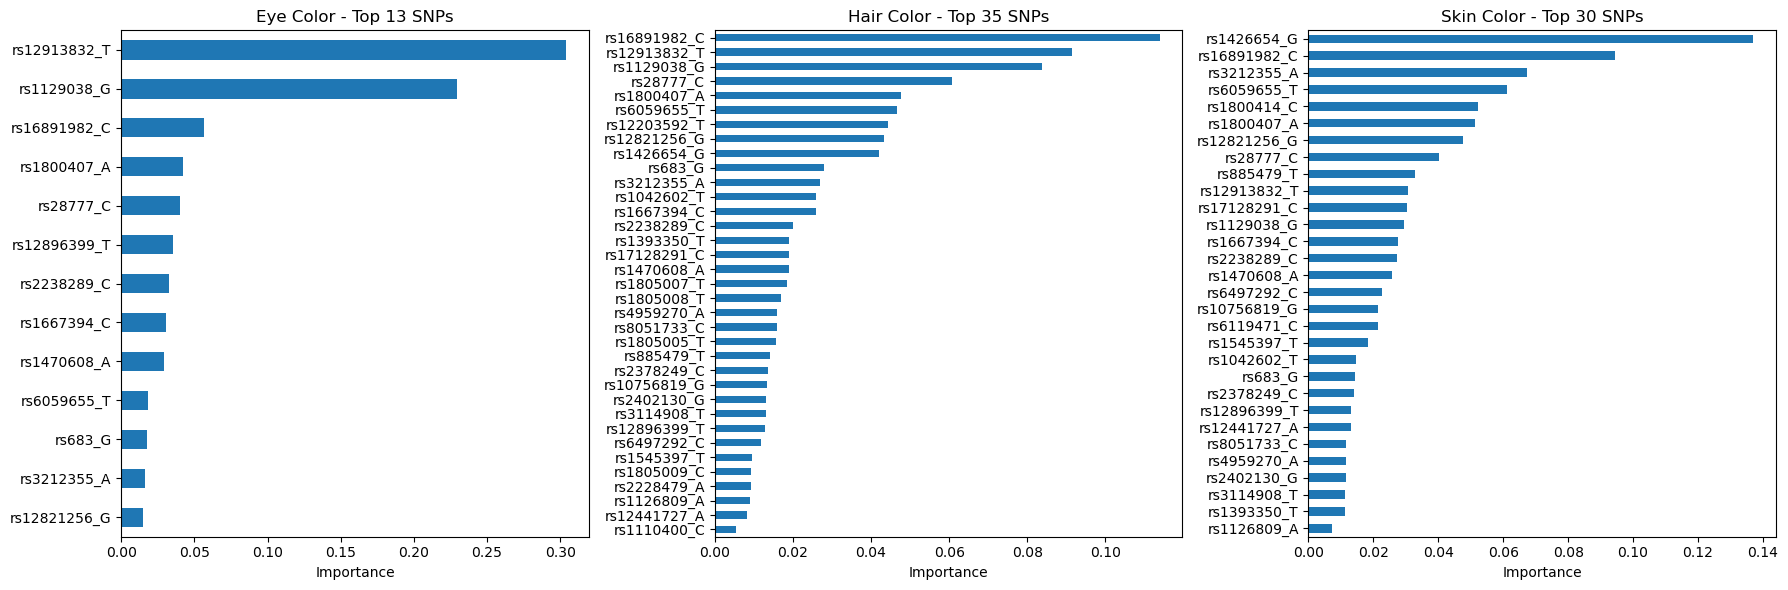

In [217]:
import matplotlib.pyplot as plt

# عدد الصفات
n_traits = len(targets_fs)

# إنشاء figure واحدة فيها subplots
fig, axes = plt.subplots(1, n_traits, figsize=(18,6))

# لو صفة واحدة بس يحولها list
if n_traits == 1:
    axes = [axes]

for ax, (label, target_col) in zip(axes, targets_fs.items()):
    
    n = target_n_features[label]
    X_fs = df[features]
    y_fs = df[target_col].astype(str)

    # Train model
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fs, y_fs)

    # Feature importance
    importances = pd.Series(rf.feature_importances_, index=features)

    # أهم SNPs
    top_importances = importances.nlargest(n).sort_values()

    # Plot داخل subplot
    top_importances.plot(kind='barh', ax=ax)
    
    ax.set_title(f"{label} - Top {n} SNPs")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()
